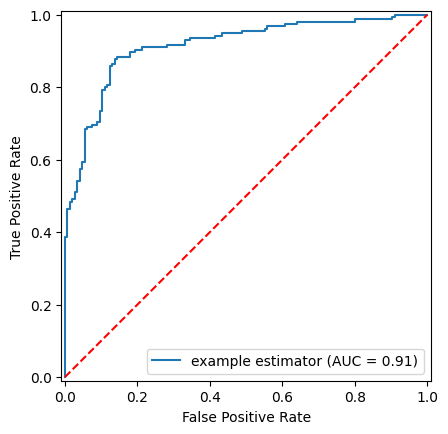

In [1]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay,  precision_recall_curve
import matplotlib.pyplot as plt

X, y = make_classification(n_samples=1000, n_features=20, n_classes=2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

clf = LogisticRegression()  # Logistics Regression Classifier
clf.fit(X_train, y_train)   # X_train and y_train for training
y_score = clf.predict_proba(X_test)[:, 1]  # Predict on x_test
fpr, tpr, thresholds = roc_curve(y_test, y_score)
auc_score = roc_auc_score(y_test, y_score)
display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=auc_score,
                                estimator_name='example estimator')
display.plot()
plt.plot([0, 1], [0, 1], linestyle='--', color='r', label='Random Classifier')  
plt.show()

In [5]:
def manual_tpr_fpr(y_true, y_pred_prob, threshold):
    y_pred = np.where(y_pred_prob >= threshold, 1, 0)
    # Get TP, FP, TN, FN
    tp = np.sum((y_pred == 1) & (y_true == 1))
    fp = np.sum((y_pred == 1) & (y_true == 0))
    tn = np.sum((y_pred == 0) & (y_true == 0))
    fn = np.sum((y_pred == 0) & (y_true == 1))
    
    # Get TPR, FPR ... 
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    
    return tpr, fpr

y_true = y_test
threshold_np = y_score
for threshold in threshold_np:
    tpr, fpr = manual_tpr_fpr(y_true, y_score, threshold)
    print(round(threshold,6), round(tpr, 6), round(fpr, 6))

0.609537 0.767742 0.103448
0.868929 0.574194 0.041379
0.513909 0.812903 0.124138
0.779089 0.658065 0.055172
0.953724 0.425806 0.006897
0.052345 0.980645 0.675862
0.227637 0.916129 0.296552
0.789347 0.63871 0.055172
0.737037 0.696774 0.082759
0.312418 0.903226 0.206897
0.966425 0.354839 0.0
0.670829 0.729032 0.096552
0.004089 1.0 0.944828
0.499307 0.832258 0.124138
0.719673 0.703226 0.096552
0.179606 0.929032 0.337931
0.064459 0.974194 0.62069
0.951292 0.432258 0.006897
0.887631 0.567742 0.041379
0.478687 0.845161 0.124138
0.994348 0.148387 0.0
0.255082 0.909677 0.268966
0.05144 0.980645 0.689655
0.102765 0.954839 0.503448
0.978692 0.277419 0.0
0.004512 1.0 0.937931
0.999622 0.019355 0.0
0.937634 0.464516 0.013793
0.011819 0.987097 0.903448
0.969792 0.329032 0.0
0.868816 0.574194 0.048276
0.988422 0.212903 0.0
0.615473 0.76129 0.103448
0.14786 0.935484 0.393103
0.312981 0.903226 0.2
0.16511 0.935484 0.358621
0.070095 0.967742 0.6
0.404965 0.883871 0.172414
0.045526 0.980645 0.737931
0.2

In [11]:
def manual_tpr_fpr(y_true, y_pred_prob, threshold):

    y_pred = np.where(y_pred_prob >= threshold, 1, 0)
    
    # Get TP, FP, TN, FN
    tp = np.sum((y_pred == 1) & (y_true == 1))
    fp = np.sum((y_pred == 1) & (y_true == 0))
    tn = np.sum((y_pred == 0) & (y_true == 0))
    fn = np.sum((y_pred == 0) & (y_true == 1))
    
    # Get TPR, FPR ... 
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    
    return tpr, fpr


def cal_auc_via_area(y_true, y_pred_prob):
    threshold_np = sorted(y_pred_prob.tolist(), reverse = True)
    auc_score_manual = 0
    prev_tpr = 0; prev_fpr = 0
    for idx, threshold in enumerate(threshold_np):
        tpr, fpr = manual_tpr_fpr(y_true, y_pred_prob, threshold)
        # print(round(threshold,6), round(tpr, 6), round(fpr, 6))
        if idx > 0:
            auc_score_manual += (fpr - prev_fpr) * (tpr + prev_tpr) / 2
        prev_tpr, prev_fpr = tpr, fpr 
    print(f"Manual Check AUC: {auc_score_manual}")

cal_auc_via_area(y_true, y_score)

Manual Check AUC: 0.9141713014460501


$$\beta$$

In [ ]:
def cal_auc(y_true, y_pred):
    sorted_indices = np.argsort(y_pred) 
    y_true = np.array(y_true)[sorted_indices]
    y_pred = np.array(y_pred)[sorted_indices]
    pos_cnt = sum(y_true)
    neg_cnt = len(y_true) - pos_cnt 
    pos_cum = 0.0
    auc = 0.0
    for i in range(len(y_true)):
        if y_true[i] == 1:
            pos_cum += 1
        else:
            auc += pos_cum 
    return auc / (pos_cnt * neg_cnt)

In [10]:
def cal_auc(y_true, y_pred_prob):
    sorted_indices = np.argsort(y_pred_prob)
    y_true = np.array(y_true)[sorted_indices]
    y_pred_prob = np.array(y_pred_prob)[sorted_indices]
    
    pos_cnt = np.sum(y_true)
    neg_cnt = len(y_true) - pos_cnt 
    auc = 0.0 
    cum_pos = 0.0 
    
    for i in range(len(y_true)):
        if y_true[i] == 0:
            cum_pos += 1
        else:
            auc += cum_pos
    auc /= (pos_cnt * neg_cnt)
    return auc 

auc_test = cal_auc(y_true, y_score)
print(auc_test)

0.9141713014460512
